In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

import os
from pathlib import Path
import sys
# Set sys path
sys.path.append(str(Path(os.getcwd()).parent))

# Set filpaths for data and figures
notebook_dir = os.getcwd()
file_path = Path(notebook_dir).parent / 'data' 

In [3]:
plt.rcParams['pdf.fonttype'] = 42  # Use Type 3 (PostScript) fonts
plt.rcParams['ps.fonttype'] = 42

In [4]:
file_path

PosixPath('/Users/jbmr/Notebooks/data_viz/data')

In [5]:
df = pd.read_csv(file_path / "AD_CSF_full_study.pg_matrix.tsv", sep='\t')
gene_dict = dict(zip(df['Protein.Group'], df['Genes']))
prot = df.set_index('Protein.Group').iloc[:,4:].T
prot.index = [a.split('/')[-1] for a in prot.index]
prot.index = [a.split('.')[0] for a in prot.index]
prot = np.log10(prot.replace(0, np.nan))

In [8]:
d_groups = pd.read_excel(file_path / "annotation of samples_AM1.5.11.xlsx")
d_groups = d_groups.dropna(subset='sample name')
d_groups = d_groups.set_index('sample name')
d_groups.index = [a.split('.')[0] for a in d_groups.index]

In [9]:
prot

Protein.Group,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J1,A0A075B6J9,A0A075B6K0,A0A075B6K2,A0A075B6K4,A0A075B6K5,...,Q9Y696,Q9Y6C2,Q9Y6N6,Q9Y6N7;Q9Y6N7-2;Q9Y6N7-4,Q9Y6N8,Q9Y6R7,Q9Y6V0,Q9Y6X5,Q9Y6Y8;Q9Y6Y8-2,Q9Y6Y9
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01,7.480833,7.302456,6.647976,6.121093,6.600015,6.554883,NaN,NaN,6.504421,6.693986,...,6.055936,6.081902,6.031582,7.102718,6.282182,7.437083,NaN,6.438099,7.426393,5.289968
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02,7.441959,7.746394,6.638860,6.231620,5.864990,6.587256,NaN,6.309164,6.668147,6.818795,...,6.423252,5.980694,6.022086,7.101586,6.245616,7.653848,NaN,6.394618,7.337615,5.657931
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03,7.235592,7.064080,6.171779,NaN,6.231123,5.679444,NaN,NaN,6.592845,6.523035,...,6.112250,6.019868,6.116644,7.210112,6.405758,7.333838,NaN,6.407980,7.653758,5.217313
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04,7.306348,7.113740,7.071628,6.247990,5.953249,NaN,NaN,5.977618,6.916297,6.583331,...,5.970826,6.392444,6.074454,7.193308,6.384404,7.281910,NaN,6.564269,7.563945,5.180619
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05,7.660938,7.722260,6.943109,6.659052,6.947768,5.891934,NaN,6.369413,6.988021,7.008975,...,6.163978,6.210072,6.165550,7.127468,6.272102,7.368897,NaN,6.496894,7.516431,5.399558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H1_82881356,7.623485,8.072801,7.797684,6.382836,6.019465,7.619711,NaN,NaN,7.151217,7.151345,...,6.337048,6.275281,6.124951,6.991466,6.012922,7.510652,6.333737,6.108562,7.048034,NaN
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H3_129190521_repeat,6.857060,7.228693,NaN,6.257892,5.734560,6.490342,NaN,5.624568,6.524322,6.530417,...,6.202314,6.224007,6.159387,7.210308,6.496517,7.017083,NaN,6.531516,7.595730,NaN
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H5_82544762_190309202008,6.988398,7.329800,6.503360,6.072121,NaN,5.834677,5.540344,5.865606,6.897995,6.781659,...,6.540621,6.169436,6.300208,7.145038,6.427223,7.262161,6.476005,6.005013,7.160448,NaN
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H7_129187195,7.103817,7.066113,6.444338,NaN,6.295103,7.086769,NaN,5.660323,6.605919,6.366115,...,6.319087,6.294654,6.253205,7.170763,6.380866,7.243284,NaN,6.397130,7.428502,NaN


In [10]:
d_groups

,collection site,age,gender,t-tau [ng/L],p-tau [ng/L],Abeta-42 [ng/L],Abeta-40 [ng/L],Abeta ratio,biochemical AD classification,clinical AD diagnosis,MMSE score,cohort sample ID,comment
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01,Sweden,71.0,f,703.0,85.0,562.0,NaN,NaN,biochemical control,NaN,NaN,ID_708,NaN
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02,Sweden,77.0,m,518.0,91.0,334.0,NaN,NaN,biochemical AD,NaN,NaN,ID_722,NaN
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03,Sweden,75.0,m,974.0,87.0,515.0,NaN,NaN,biochemical AD,NaN,NaN,ID_734,NaN
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04,Sweden,72.0,f,950.0,109.0,394.0,NaN,NaN,biochemical AD,NaN,NaN,ID_742,NaN
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05,Sweden,63.0,f,873.0,88.0,234.0,NaN,NaN,biochemical AD,NaN,NaN,ID_757,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H3_129190521_repeat,Berlin,69.0,f,1945.0,NaN,699.0,12140.0,0.057578,biochemical AD,AD,17.0,ID_0129190521,NaN
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H5_82544762_190309202008,Berlin,73.0,m,299.0,NaN,1420.0,16571.0,0.085692,biochemical control,non-AD,28.0,ID_0082544762,NaN
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H7_129187195,Berlin,71.0,f,262.0,NaN,639.0,9663.0,0.066129,biochemical control,non-AD,28.0,ID_0129187195,NaN
20190228_QX1_PhGe_SA_EASY12-10_Deigendesch_H9_82875993,Berlin,83.0,m,289.0,NaN,1436.0,11285.0,0.127249,biochemical control,non-AD,24.0,ID_0082875993,NaN


# categorical correlation

In [11]:
pd.crosstab(d_groups['collection site'], d_groups['gender'], margins=True, margins_name='Sum')

gender,f,m,Sum
collection site,,,
Berlin,42,41,83
Kiel,9,7,16
Magdeburg,24,14,38
Sweden,24,36,60
Sum,99,98,197


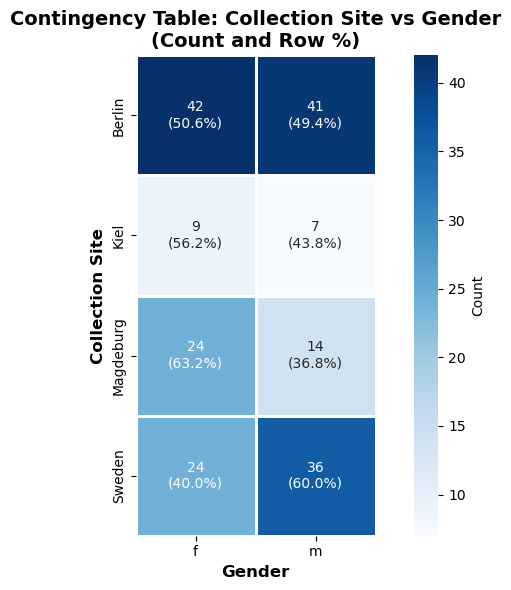

In [12]:
# Create contingency table
ct = pd.crosstab(d_groups['collection site'], d_groups['gender'])

# Calculate percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Create figure
plt.figure(figsize=(8, 6))

# Create heatmap with both counts and percentages
ax = sns.heatmap(ct, 
                 annot=ct.astype(str) + '\n(' + ct_pct.round(1).astype(str) + '%)',
                 fmt='',              # Empty format since we're using custom annotations
                 cmap='Blues',
                 cbar_kws={'label': 'Count'},
                 linewidths=1,
                 linecolor='white',
                 square=True)

plt.title('Contingency Table: Collection Site vs Gender\n(Count and Row %)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.ylabel('Collection Site', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

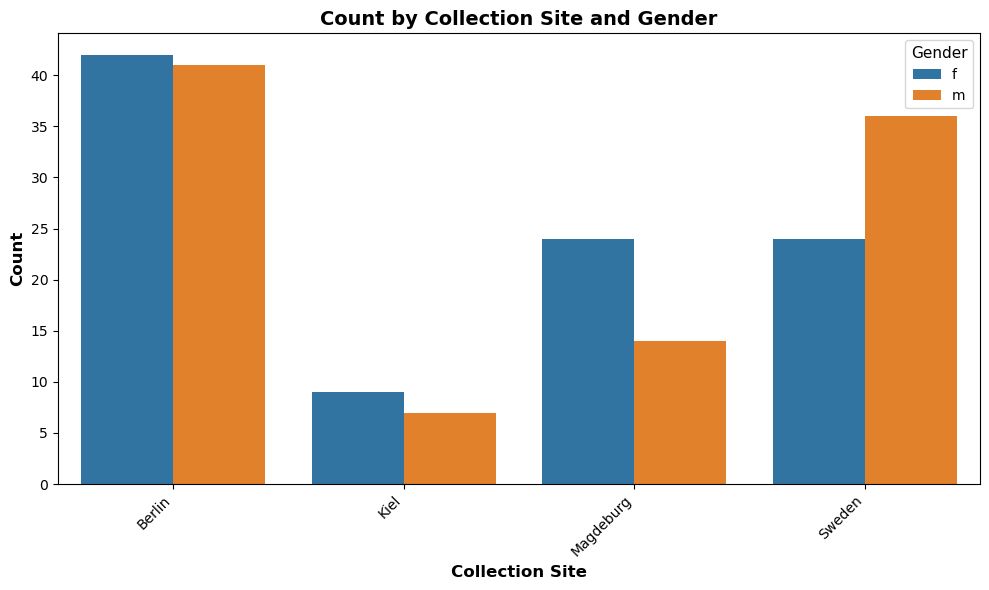

In [13]:
# Convert to long format for plotting
ct_long = ct.reset_index().melt(id_vars='collection site', 
                                var_name='gender', 
                                value_name='count')

# Create the barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=ct_long, x='collection site', y='count', hue='gender')
plt.title('Count by Collection Site and Gender', fontsize=14, fontweight='bold')
plt.xlabel('Collection Site', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(ct)

In [15]:
chi2

np.float64(5.28868727277041)

In [16]:
p_value

np.float64(0.151838143470486)

# ask claude to do some more elaborate plots and statistics

/var/folders/8z/kscfzvs51qn3b6j4j1fcns100000gn/T/ipykernel_89887/1231758871.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


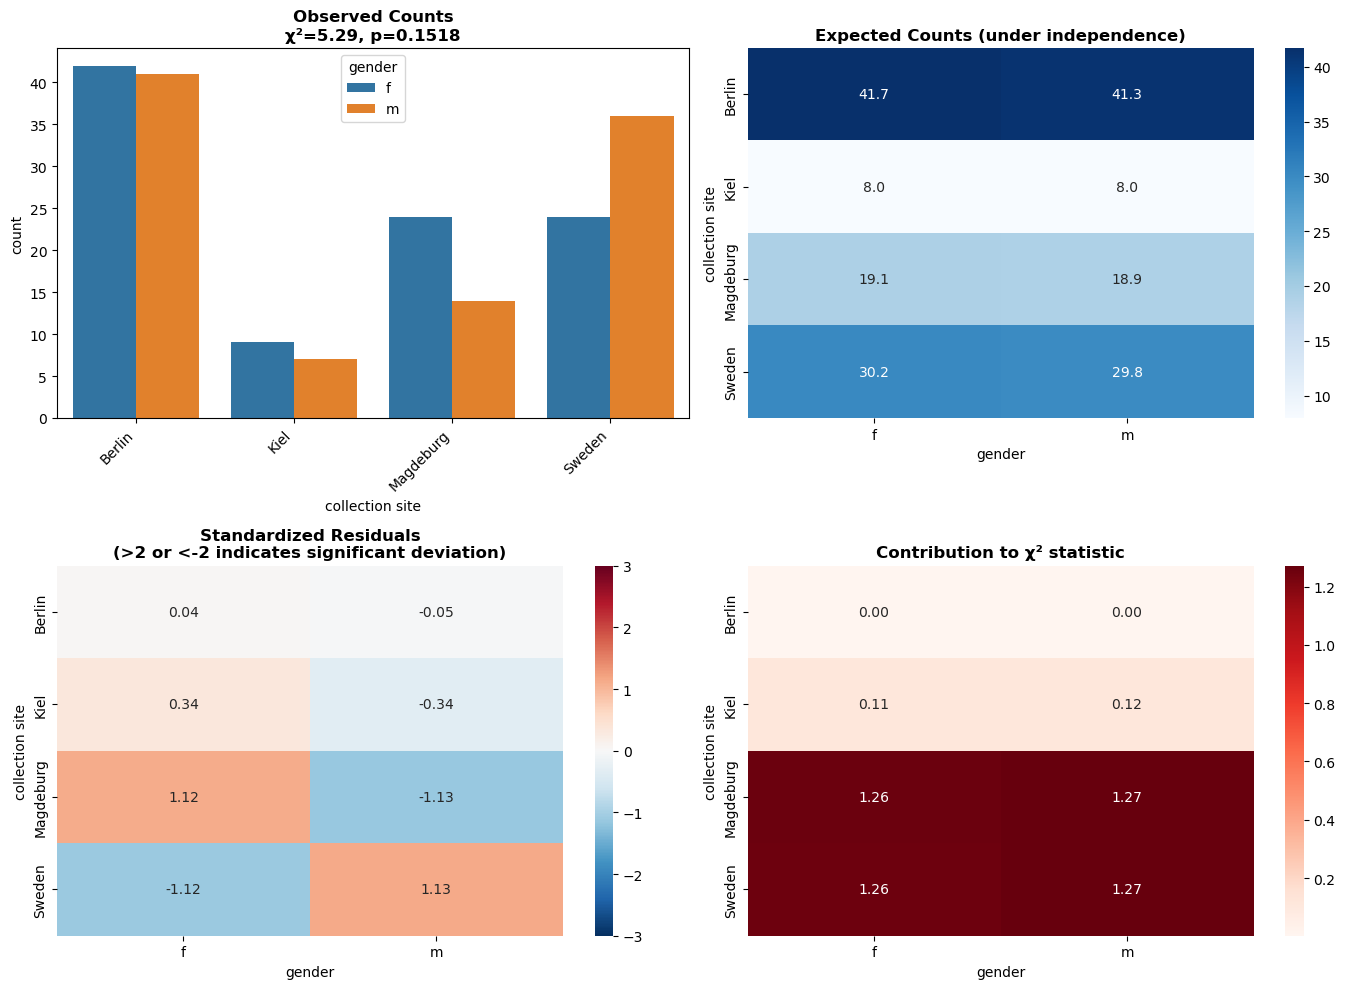


Chi-square Test Interpretation:
H0: Collection site and gender are independent
H1: Collection site and gender are associated

Test statistic: χ² = 5.2887
p-value: 0.1518
Degrees of freedom: 3

Conclusion at α=0.05: Fail to reject H0. No significant association between collection site and gender.

Cramér's V (effect size): 0.164
Effect size interpretation: Medium


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Create contingency table
ct = pd.crosstab(d_groups['collection site'], d_groups['gender'])

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(ct)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Observed counts (barplot)
ax1 = axes[0, 0]
ct_long = ct.reset_index().melt(id_vars='collection site', var_name='gender', value_name='count')
sns.barplot(data=ct_long, x='collection site', y='count', hue='gender', ax=ax1)
ax1.set_title(f'Observed Counts\nχ²={chi2:.2f}, p={p_value:.4f}', fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 2. Expected counts (heatmap)
ax2 = axes[0, 1]
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
sns.heatmap(expected_df, annot=True, fmt='.1f', cmap='Blues', ax=ax2)
ax2.set_title('Expected Counts (under independence)', fontweight='bold')

# 3. Standardized residuals (heatmap)
ax3 = axes[1, 0]
residuals = (ct - expected) / np.sqrt(expected)
sns.heatmap(residuals, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-3, vmax=3, ax=ax3)
ax3.set_title('Standardized Residuals\n(>2 or <-2 indicates significant deviation)', fontweight='bold')

# 4. Contribution to chi-square (heatmap)
ax4 = axes[1, 1]
contributions = (ct - expected)**2 / expected
sns.heatmap(contributions, annot=True, fmt='.2f', cmap='Reds', ax=ax4)
ax4.set_title('Contribution to χ² statistic', fontweight='bold')

plt.tight_layout()
plt.savefig(file_path / 'figures' / 'chi_square_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print interpretation
print("\nChi-square Test Interpretation:")
print(f"H0: Collection site and gender are independent")
print(f"H1: Collection site and gender are associated")
print(f"\nTest statistic: χ² = {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nConclusion at α=0.05: ", end="")
if p_value < 0.05:
    print(f"Reject H0. There is a significant association between collection site and gender.")
else:
    print(f"Fail to reject H0. No significant association between collection site and gender.")

# Additional statistics
from scipy.stats import contingency
cramers_v = np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1)))
print(f"\nCramér's V (effect size): {cramers_v:.3f}")
print(f"Effect size interpretation: ", end="")
if cramers_v < 0.1:
    print("Small")
elif cramers_v < 0.3:
    print("Medium")
else:
    print("Large")

# Categorical - numerical correlation

In [18]:
import plotly.express as px
fig = px.box(d_groups,
             y='age', x='gender',
             title='gender vs age',
             points='all')
fig.update_layout(
    width=800,
    height=600,
)

fig.show()

In [19]:
from scipy import stats

# Extract age data for each gender group
male_ages = d_groups[d_groups['gender'] == 'm']['age']
female_ages = d_groups[d_groups['gender'] == 'f']['age']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(male_ages, female_ages, nan_policy='omit')

In [20]:
t_stat, p_value

(np.float64(1.0802400908111993), np.float64(0.28136951408520344))

In [21]:

fig = px.box(d_groups,
             y='age', 
             x='biochemical AD classification',
             title='AD vs t-tau [ng/L]',
             points='all')
fig.update_layout(
    width=800,
    height=600,
)

fig.show()

In [22]:

fig = px.box(d_groups,
             y='t-tau [ng/L]', 
             x='biochemical AD classification',
             title='AD vs t-tau [ng/L]',
             points='all')
fig.update_layout(
    width=800,
    height=600,
)

fig.show()

In [23]:
from scipy import stats

# Extract age data for each gender group
AD = d_groups[d_groups['biochemical AD classification'] == 'biochemical AD']['t-tau [ng/L]']
ctrl = d_groups[d_groups['biochemical AD classification'] == 'biochemical control']['t-tau [ng/L]']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(AD, ctrl, nan_policy='omit')

In [24]:
t_stat, p_value

(np.float64(14.309512603028796), np.float64(1.8451211800892216e-31))

# Numerical correlation

In [25]:
fig = px.scatter(d_groups,
                 x='t-tau [ng/L]',
                 y='p-tau [ng/L]',
                 color='biochemical AD classification',
                 title='AD vs t-tau [ng/L]')   
fig.update_layout(
    width=800,
    height=600,
)
fig.show()

In [26]:
df_clean = d_groups[['t-tau [ng/L]', 'p-tau [ng/L]']].dropna()

r, p_value = stats.pearsonr(df_clean['t-tau [ng/L]'], df_clean['p-tau [ng/L]'])

In [27]:
r, p_value

(np.float64(0.9216265118568728), np.float64(3.023902640392415e-41))

In [28]:
fig = px.scatter(d_groups,
                 x='t-tau [ng/L]',
                 y='p-tau [ng/L]',
                 color='biochemical AD classification',
                 title=f'AD vs t-tau [ng/L]<br><sub>Pearson r = {r:.3f}, p = {p_value:.4f}</sub>')


slope, intercept = np.polyfit(df_clean['t-tau [ng/L]'], df_clean['p-tau [ng/L]'], 1)
x_range = np.array([df_clean['t-tau [ng/L]'].min(), df_clean['t-tau [ng/L]'].max()])
y_range = slope * x_range + intercept

fig.add_scatter(x=x_range, y=y_range, 
                mode='lines',
                name=f'r={r:.3f}',
                line=dict(color='black', dash='dash'))

fig.update_layout(
    width=800,
    height=600,
)
fig.show()

In [41]:
fig = px.scatter(d_groups,
                 x='t-tau [ng/L]',
                 y='age',
                 color='biochemical AD classification',
                 title='AD vs t-tau [ng/L]')   
fig.update_layout(
    width=800,
    height=600,
)
fig.show()